<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Var-Reduction-Speed" data-toc-modified-id="Var-Reduction-Speed-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Var Reduction Speed</a></span></li><li><span><a href="#Var-Reduction" data-toc-modified-id="Var-Reduction-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Var Reduction</a></span><ul class="toc-item"><li><span><a href="#Dimensional-wise-Test-Taker-Percentage" data-toc-modified-id="Dimensional-wise-Test-Taker-Percentage-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Dimensional-wise Test Taker Percentage</a></span></li></ul></li><li><span><a href="#Posterior-Mean-vs-True-Theta" data-toc-modified-id="Posterior-Mean-vs-True-Theta-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Posterior Mean vs True Theta</a></span></li><li><span><a href="#Posterior-Mean-v.s-Oracle-Mean" data-toc-modified-id="Posterior-Mean-v.s-Oracle-Mean-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Posterior Mean v.s Oracle Mean</a></span></li><li><span><a href="#Posterior-Median-v.s-Oracle-Median" data-toc-modified-id="Posterior-Median-v.s-Oracle-Median-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Posterior Median v.s Oracle Median</a></span></li><li><span><a href="#Posterior-First-Quantile-v.s-Oracle-First-Quantile" data-toc-modified-id="Posterior-First-Quantile-v.s-Oracle-First-Quantile-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Posterior First Quantile v.s Oracle First Quantile</a></span></li><li><span><a href="#Posterior-Third-Quantile-v.s-Oracle-Third-Quantile" data-toc-modified-id="Posterior-Third-Quantile-v.s-Oracle-Third-Quantile-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Posterior Third Quantile v.s Oracle Third Quantile</a></span></li><li><span><a href="#Training-Rewards-And-Validation-Loss" data-toc-modified-id="Training-Rewards-And-Validation-Loss-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Training Rewards And Validation Loss</a></span><ul class="toc-item"><li><span><a href="#Process-Rewards" data-toc-modified-id="Process-Rewards-8.1"><span class="toc-item-num">8.1&nbsp;&nbsp;</span>Process Rewards</a></span></li></ul></li></ul></div>

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
import yaml
import argparse
import pandas as pd
import bayesian_cat as bcat
sns.set()

In [6]:
model_dir = pathlib.Path.home().joinpath(pathlib.Path("bayesian-cat", "models"))
model_filenames = ["standarized_5_factor_mixed_s02_kl_eap_50.pickle", "standarized_5_factor_mixed_s02_kl_pos_50.pickle", "standarized_5_factor_mixed_s02_mi_sir_50.pickle", "standarized_5_factor_mixed_s02_predictive_variance_e_50.pickle"]
# previous baseline model
model_keys = ["EAP","Max Pos", "MI", "Max Var"]
models = {}
for i, filename in enumerate(model_filenames):
    with open(model_dir.joinpath("sim_models").joinpath(filename), "rb") as input_file:
        models[model_keys[i]] = pickle.load(input_file)
# current deep q learning
q_cat_dir = model_dir.joinpath("q_learning").joinpath("Q-CAT")
Q_model_filenames = ["x09_s03_QCAT_50_retrain_retrainv1_NN_x09_s01_mixed_grid_500_200_5_4_150000_first3-0-1_detailed_v4_1.5e-05_128_30000_1000_0.16_retrain_fn_24000.pt_fn_11000.pt_final.pickle"]
    

Q_learning_keys = ["Q-0.16"]
model_keys += Q_learning_keys
for i, filename in enumerate(Q_model_filenames):
    with open(q_cat_dir.joinpath(filename), "rb") as input_file:
        models[Q_learning_keys[i]] = pickle.load(input_file)

# read params and data
n, max_items=500, 50
num_models = len(model_keys)
model = models["MI"]
m,k = model.m, model.k
true_thetas = model.true_thetas
alphas = model.alphas
intercepts = model.intercepts

In [7]:
# Oracle Distribution
# params = {"thetas": true_thetas, "alphas": alphas, "intercepts": intercepts}
# simulated_item_response = bcat.util.probit_mirt_binary_data(params).values
# oracle = bcat.OracleCAT(simulated_item_response, params)
# bayes_oracle = oracle.sun_inference(1000, return_samples=True)
# bayes_oracle["response"] = simulated_item_response
# with open('bayesian_oracle_exact_s01_mixed_grid_500_200_5_4.pickle', 'wb') as handle:
#      pickle.dump(bayes_oracle, handle, protocol=pickle.HIGHEST_PROTOCOL)
with open('bayesian_oracle_exact_s01_mixed_grid_500_200_5_4.pickle', 'rb') as handle:
    bayes_oracle = pickle.load(handle)

In [8]:
true_samples= bayes_oracle["samples"][:n]
true_quantiles = {0.25:np.zeros((n, k)), 0.5:np.zeros((n, k)), 0.75 :np.zeros((n, k)), "oracle_mean": np.zeros((n,k))} # keys: 1, 2, 3 Vals: [],[],[]
for i in range(n):
    temp_sample = true_samples[i]
    for quantile in true_quantiles.keys():
        if quantile == "oracle_mean":
            true_quantiles[quantile][i]= np.mean(temp_sample, axis=0)
        else:
            true_quantiles[quantile][i] = np.quantile(temp_sample, quantile, axis=0)

# Var Reduction Speed

In [9]:
# Record Quantile result
# Quantile_result key is model, value is a disctionary: with key as 

with open("quantile_result_new_eval_first_3.pickle", 'rb') as handle:
    quantile_result = pickle.load(handle)

# quantile_result = {}
# for model_name, model in models.items():
#     if model_name not in quantile_result:
#         print(model_name)
#         model_quantiles = {}
#         max_var_array = np.zeros((n, max_items))
#         max_mse_array = np.zeros((n, max_items))
#         if model_name[0] != "Q":
#             d1_tensor = model.tts.d1_tensor[:n, :max_items, :]
#             d2_array = model.tts.d2_array[:n, :max_items]
#             s_array = model.tts.s_array[:n, :max_items]
#         else:
#             d1_tensor = model.tts.d1_tensor[:n, 1:(max_items+1), :]
#             d2_array = model.tts.d2_array[:n, 1:(max_items+1)]
#             s_array = model.tts.s_array[:n, 1:(max_items+1)]
#         for j in range(max_items):
#             model_quantiles[j] = {0.25:np.zeros((n, k)), 0.5:np.zeros((n, k)), 0.75 :np.zeros((n, k)),
#                                  "var": np.zeros((n,k))}
#             model_samples = bcat.sample_from_sun_all(1000, d1_tensor[:,:(j+1),:], d2_array[:, :(j+1)],  s_array[:, :(j+1)], num_workers =8)
#             model_quantiles[j]["var"] = np.var(model_samples, axis=1)
#             for quantile in true_quantiles.keys():
#                 if quantile == "oracle_mean":
#                     model_quantiles[j][quantile] = np.mean(model_samples, axis=1)
#                 else:
#                     model_quantiles[j][quantile] = np.quantile(model_samples, quantile, axis=1)
#         quantile_result[model_name] = model_quantiles

# with open("quantile_result_new_eval_first_3.pickle", 'wb') as handle:
#     pickle.dump(quantile_result, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Var Reduction

## Dimensional-wise Test Taker Percentage

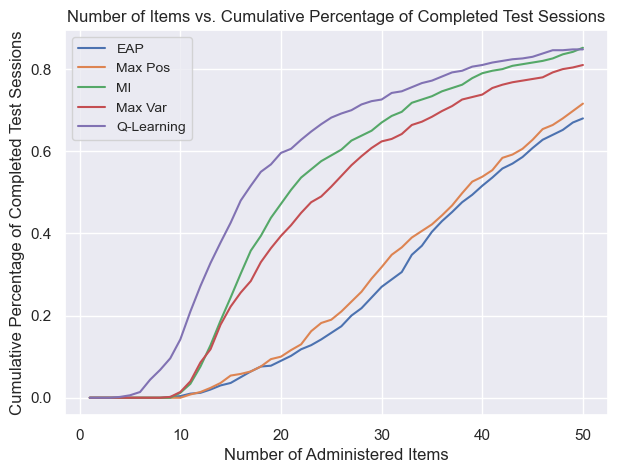

In [12]:
# Ensure figure is explicitly created
fig, ax = plt.subplots(figsize=(7,5))
x_vals = np.arange(1,max_items+1,1)
threshold = 0.16
for model_name, model in models.items():
    nonterminated_set = set(np.arange(0, n, 1))
    percentage = np.zeros(max_items)
    
    for h in range(max_items):
        cur_nonterminated = np.where(np.max(quantile_result[model_name][h]["var"][:, :3], axis=1) > threshold)[0]
        nonterminated_set = nonterminated_set.intersection(cur_nonterminated)
        percentage[h] = (n - len(nonterminated_set)) / n
    if model_name[0] == "Q":
        model_name = "Q-Learning"
    ax.plot(x_vals, percentage, label=model_name)

# Labels and legend
ax.set_title("Number of Items vs. Cumulative Percentage of Completed Test Sessions", fontsize=12)
ax.set_xlabel("Number of Administered Items", fontsize=12)
ax.set_ylabel("Cumulative Percentage of Completed Test Sessions", fontsize=12)
ax.legend(fontsize=10)

# Save the figure BEFORE plt.show()
plt.savefig("simulation_completion_rate.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.show()


In [16]:
threshold = 0.16
model_names = list(models.keys())
average_termination = {}
for model_name, model in models.items():
    count = 0
    nonterminated_set = set(np.arange(0,n,1))
    for h in range(max_items):
        cur_nonterminated = np.where(np.max(quantile_result[model_name][h]["var"][:, :3], axis=1) > threshold)[0]
        nonterminated_set = nonterminated_set.intersection(cur_nonterminated)
        count+= len(nonterminated_set)
    average_termination[model_name] = count/n

In [18]:
average_termination

{'EAP': 37.562,
 'Max Pos': 36.6,
 'MI': 25.804,
 'Max Var': 27.722,
 'Q-0.16': 22.41}

# Posterior Mean vs True Theta

In [ ]:
# x_vals = np.arange(1,max_items+1,1)
# test_taker_percentage = {}
# fig, axs = plt.subplots(1, 3, figsize=(20, 7))
# for dim in range(3):
#     for model_name, model in models.items():
#         mse = np.zeros(max_items)
#         for h in range(max_items):
#             mse[h] = np.mean(np.square(quantile_result[model_name][h]["oracle_mean"][:, dim] - true_thetas[:, dim]))
#         axs[dim].plot(x_vals, mse, label=model_name)
#     axs[dim].set_xlabel("Number of items")
#     axs[dim].set_ylabel("MSE Between Posterior Mean and Truth")
#     axs[dim].legend()
#     axs[dim].set_title("Dim {}: Number of Items v.s Estimation MSE".format(dim))


In [ ]:
# winshare_tables = np.zeros((len(models.keys()),3))
# model_names = list(models.keys())
# for dim in range(3):
#     mse_table = np.zeros((n, len(model_names)))
#     for i, model_name in enumerate(model_names):
#         mse_table[:, i] = np.square(quantile_result[model_name][max_items-1]["oracle_mean"][:, dim] - true_thetas[:, dim])
#     winners = np.argmin(mse_table, axis=1)
#     winshare_columns = np.zeros(len(model_names))
#     for i, model_name in enumerate(model_names):
#         winshare_columns[i] = np.sum(winners==i)/n
#     winshare_tables[:, dim] = winshare_columns
        
# winshare_tables= pd.DataFrame(winshare_tables, columns = ["dim"+str(dim) for dim in range(3)])
# winshare_tables.index = model_names
# winshare_tables

In [ ]:
# winshare_tables["average_items"] = list(average_termination.values())
# winshare_tables["Selection Time (s)"] = np.ones(len(model_names))

In [ ]:
#winshare_tables

In [ ]:
#average_termination

# Posterior Mean v.s Oracle Mean

In [ ]:
# x_vals = np.arange(1,max_items+1,1)
# test_taker_percentage = {}
# fig, axs = plt.subplots(1, 3, figsize=(20, 7))
# for dim in range(3):
#     for model_name, model in models.items():
#         mse = np.zeros(max_items)
#         for h in range(max_items):
#             mse[h] = np.mean(np.square(quantile_result[model_name][h]["oracle_mean"][:, dim] - true_quantiles["oracle_mean"][:, dim]))
#         axs[dim].plot(x_vals, mse, label=model_name)
#     axs[dim].set_xlabel("Number of items")
#     axs[dim].set_ylabel("MSE Between Posterior Mean and Oracle Mean")
#     axs[dim].legend()
#     axs[dim].set_title("Dim {}: Number of Items v.s Estimation MSE".format(dim))


In [ ]:
max_items = 50
x_vals = np.arange(1, max_items+1, 1)
test_taker_percentage = {}
fig, axs = plt.subplots(1, 3, figsize=(20, 7))

# Plot and save
for dim in range(3):
    for model_name, model in models.items():
        mse = np.zeros(max_items)
        for h in range(max_items):
            mse[h] = np.mean(np.square(quantile_result[model_name][h]["oracle_mean"][:, dim] - true_quantiles["oracle_mean"][:, dim]))
        if model_name[0] == "Q":
            model_name = "Q-Learning"
        axs[dim].plot(x_vals, mse, label=model_name)
    
    axs[dim].set_xlabel("Number of items")
    axs[dim].set_ylabel("MSE Between Posterior Mean and Oracle Mean")
    axs[dim].legend()
    axs[dim].set_title("Dim {}: Number of Items v.s Estimation MSE".format(dim))

# Save the figure to a PDF file
plt.savefig("simulation_mean_mse.pdf", format="pdf")

# Show the plot
plt.show()

In [ ]:
max_items =20
winshare_tables = np.zeros((len(models.keys()),3))
model_names = list(models.keys())
for dim in range(3):
    mse_table = np.zeros((n, len(model_names)))
    for i, model_name in enumerate(model_names):
        mse_table[:, i] = np.square(quantile_result[model_name][max_items-1]["oracle_mean"][:, dim] -  true_quantiles["oracle_mean"][:, dim])
    winners = np.argmin(mse_table, axis=1)
    winshare_columns = np.zeros(len(model_names))
    for i, model_name in enumerate(model_names):
        winshare_columns[i] = np.sum(winners==i)/n
    winshare_tables[:, dim] = winshare_columns
        
winshare_tables= pd.DataFrame(winshare_tables, columns = ["dim"+str(dim) for dim in range(3)])
winshare_tables.index = model_names
winshare_tables

In [ ]:
winshare_tables["avg_termination"] = winshare_tables.index.map(average_termination) 

In [ ]:
winshare_tables

In [ ]:
winshare_tables.transpose()

# Posterior Median v.s Oracle Median

In [ ]:
# x_vals = np.arange(1,max_items+1,1)
# test_taker_percentage = {}
# fig, axs = plt.subplots(1, 3, figsize=(20, 7))
# for dim in range(3):
#     for model_name, model in models.items():
#         mse = np.zeros(max_items)
#         for h in range(max_items):
#             mse[h] = np.mean(np.square(quantile_result[model_name][h][0.5][:, dim] - true_quantiles[0.5][:, dim]))
#         axs[dim].plot(x_vals, mse, label=model_name)
#     axs[dim].set_xlabel("Number of items")
#     axs[dim].set_ylabel("MSE Between Posterior Median and Oracle Median")
#     axs[dim].legend()
#     axs[dim].set_title("Dim {}: Number of Items v.s Estimation MSE".format(dim))


In [ ]:
max_items = 50
x_vals = np.arange(1,max_items+1,1)
test_taker_percentage = {}
fig, axs = plt.subplots(1, 3, figsize=(20, 7))
for dim in range(3):
    for model_name, model in models.items():
        mse = np.zeros(max_items)
        for h in range(max_items):
            mse[h] = np.mean(np.square(quantile_result[model_name][h][0.5][:, dim] - true_thetas[:, dim]))
        if model_name[0] =="Q":
            model_name = "Q-Learning"
        axs[dim].plot(x_vals, mse, label=model_name)
    axs[dim].set_xlabel("Number of items")
    axs[dim].set_ylabel("MSE Between Posterior Median and Oracle Median")
    axs[dim].legend()
    axs[dim].set_title("Dim {}: Number of Items v.s Estimation MSE".format(dim))

# Save the figure to a PDF file
plt.savefig("simulation_median_mse.pdf", format="pdf")

# Show the plot
plt.show()

In [ ]:
winshare_tables = np.zeros((len(models.keys()),3))
model_names = list(models.keys())
max_items =20
for dim in range(3):
    mse_table = np.zeros((n, len(model_names)))
    for i, model_name in enumerate(model_names):
        mse_table[:, i] = np.square(quantile_result[model_name][max_items-1][0.5][:, dim] -  true_quantiles[0.5][:, dim])
    winners = np.argmin(mse_table, axis=1)
    winshare_columns = np.zeros(len(model_names))
    for i, model_name in enumerate(model_names):
        winshare_columns[i] = np.sum(winners==i)/n
    winshare_tables[:, dim] = winshare_columns
        
winshare_tables= pd.DataFrame(winshare_tables, columns = ["dim"+str(dim) for dim in range(3)])
winshare_tables.index = model_names
winshare_tables

# Posterior First Quantile v.s Oracle First Quantile

In [ ]:
max_items = 50
x_vals = np.arange(1,max_items+1,1)
test_taker_percentage = {}
fig, axs = plt.subplots(1, 3, figsize=(20, 7))
for dim in range(3):
    for model_name, model in models.items():
        mse = np.zeros(max_items)
        for h in range(max_items):
            mse[h] = np.mean(np.square(quantile_result[model_name][h][0.25][:, dim] - true_quantiles[0.25][:, dim]))
        if model_name[0] == "Q":
            model_name = "Q-learning"
        axs[dim].plot(x_vals, mse, label=model_name)
    axs[dim].set_xlabel("Number of items")
    axs[dim].set_ylabel("MSE Between Posterior First Quantile and Oracle First Quantile")
    axs[dim].legend()
    axs[dim].set_title("Dim {}: Number of Items v.s Estimation MSE".format(dim))

# Save the figure to a PDF file
plt.savefig("simulation_1st_quantile_mse.pdf", format="pdf")

# Show the plot
plt.show()

In [ ]:
max_items = 20
winshare_tables = np.zeros((len(models.keys()),3))
model_names = list(models.keys())
for dim in range(3):
    mse_table = np.zeros((n, len(model_names)))
    for i, model_name in enumerate(model_names):
        mse_table[:, i] = np.square(quantile_result[model_name][max_items-1][0.25][:, dim] -  true_quantiles[0.25][:, dim])
    winners = np.argmin(mse_table, axis=1)
    winshare_columns = np.zeros(len(model_names))
    for i, model_name in enumerate(model_names):
        winshare_columns[i] = np.sum(winners==i)/n
    winshare_tables[:, dim] = winshare_columns
        
winshare_tables= pd.DataFrame(winshare_tables, columns = ["dim"+str(dim) for dim in range(3)])
winshare_tables.index = model_names
winshare_tables

# Posterior Third Quantile v.s Oracle Third Quantile

In [ ]:
max_items  = 50
x_vals = np.arange(1,max_items+1,1)
test_taker_percentage = {}
fig, axs = plt.subplots(1, 3, figsize=(20, 7))
for dim in range(3):
    for model_name, model in models.items():
        mse = np.zeros(max_items)
        for h in range(max_items):
            mse[h] = np.mean(np.square(quantile_result[model_name][h][0.75][:, dim] - true_quantiles[0.75][:, dim]))
        if model_name[0] == "Q":
            model_name = "Q-learning"
        axs[dim].plot(x_vals, mse, label=model_name)
    axs[dim].set_xlabel("Number of items")
    axs[dim].set_ylabel("MSE Between Posterior Third Quantile and Oracle Third Quantile")
    axs[dim].legend()
    axs[dim].set_title("Dim {}: Number of Items v.s Estimation MSE".format(dim))

# Save the figure to a PDF file
plt.savefig("simulation_3rd_quantile_mse.pdf", format="pdf")

# Show the plot
plt.show()

In [ ]:
max_items = 20
winshare_tables = np.zeros((len(models.keys()),3))
model_names = list(models.keys())
for dim in range(3):
    mse_table = np.zeros((n, len(model_names)))
    for i, model_name in enumerate(model_names):
        mse_table[:, i] = np.square(quantile_result[model_name][max_items-1][0.75][:, dim] -  true_quantiles[0.75][:, dim])
    winners = np.argmin(mse_table, axis=1)
    winshare_columns = np.zeros(len(model_names))
    for i, model_name in enumerate(model_names):
        winshare_columns[i] = np.sum(winners==i)/n
    winshare_tables[:, dim] = winshare_columns
        
winshare_tables= pd.DataFrame(winshare_tables, columns = ["dim"+str(dim) for dim in range(3)])
winshare_tables.index = model_names
winshare_tables

# Training Rewards And Validation Loss

Note training was interuped for the simulation, since it took more than 3 days. I saved the training logs in to two different files

In [ ]:
with open("detailed_log.pickle", "rb") as input_file:
    training_log1 = pickle.load(input_file)
with open("retrain_retrainv1_detailed_log.pickle", "rb") as input_file:
    training_log2 = pickle.load(input_file)

In [ ]:
len(training_log1)

In [ ]:
len(training_log2)

## Process Rewards

In [ ]:
episode_rewards1 = np.array([training_log1[i]["learned_reward"] for i in range(len(training_log1))])
episode_rewards2 = np.array([training_log2[i]["learned_reward"] for i in range(len(training_log2))])
episode_rewards = np.concatenate((episode_rewards1, episode_rewards2))
reward_period = 500
plot_length = episode_rewards.shape[0]//reward_period
average_rewards = np.zeros(plot_length)
for i in range(plot_length):
    average_rewards[i] = np.mean(episode_rewards[(i*reward_period):((i+1)*reward_period)])

# for i, x in enumerate(average_rewards):
# 	print((i +1)*reward_period, x)


In [ ]:
plt.plot(np.arange(0, 40000, 500), average_rewards)

In [ ]:
episode_loss1 = np.array([training_log1[i]["learned_loss"] for i in range(len(training_log1))])
episode_loss2 = np.array([training_log2[i]["learned_loss"] for i in range(len(training_log2))])
episode_loss = np.concatenate((episode_loss1, episode_loss2))
reward_period = 500
plot_length = episode_rewards.shape[0]//reward_period
average_loss = np.zeros(plot_length)
for i in range(plot_length):
    average_loss[i] = np.mean(episode_loss[(i*reward_period):((i+1)*reward_period)])

# for i, x in enumerate(average_loss):
# 	print((i +1)*reward_period, x)


# episode_loss = np.array([training_log[i]["learned_loss"] for i in range(len(training_log))])
# reward_period = 1000
# plot_length = episode_loss.shape[0]//reward_period
# average_loss = np.zeros(plot_length)
# for i in range(plot_length):
#     average_loss[i] = np.mean(episode_loss[(i*reward_period):((i+1)*reward_period)])

# for i, x in enumerate(average_loss):
# 	print((i +1)*reward_period, x)


In [ ]:
plt.plot(np.arange(0, 40000, 500), average_loss)

In [ ]:
x_vals = np.arange(0, 40000, 500)
fig, axs = plt.subplots(1, 2, figsize=(20, 7))
axs[0].plot(x_vals, average_rewards)
axs[0].set_xlabel("Number of Episodes")
axs[0].set_ylabel("Average Rewards Over Every 500 Episodes")
axs[0].set_title("Increase of Rewards During Double Q-Learning")
axs[1].plot(x_vals, average_loss)
axs[1].set_xlabel("Number of Episodes")
axs[1].set_ylabel("Average Validation Loss Over Every 500 Episodes")
axs[1].set_title("Decrease of Validation Loss During Double Q-Learning")
# Save the figure to a PDF file
plt.savefig("training_dynamics_simulation.pdf", format="pdf")

# Show the plot
plt.show()